# Supermarket Sales Analysis

In this notebook we will:
1. Load and explore the dataset
2. Clean and prepare the data
3. Analyse sales, products, customers, and payments
4. Visualise every finding with simple charts

**Libraries used:** `pandas` · `numpy` · `matplotlib`

---
## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make all charts look clean and readable
plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print('Libraries imported successfully!')

Libraries imported successfully!


---
## Step 2 — Load the Dataset

In [2]:
df = pd.read_csv('supermarket_sales_data.csv')

print('Shape of the dataset:', df.shape)
print('\nFirst 5 rows:')
df.head()

Shape of the dataset: (100, 13)

First 5 rows:


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment
0,427-67-9288,C,Naypyitaw,Member,Female,Food and beverages,60.56,5,15.14,317.94,02/14/2019,13:42,Cash
1,435-60-3264,A,Mandalay,Normal,Female,Electronic accessories,20.35,4,4.07,85.47,02/24/2019,20:03,Credit card
2,748-84-1701,B,Naypyitaw,Normal,Male,Health and beauty,24.06,5,6.02,126.32,02/03/2019,19:55,Credit card
3,146-53-1747,C,Naypyitaw,Normal,Female,Health and beauty,82.52,7,28.88,606.52,01/17/2019,8:04,Credit card
4,727-54-5172,A,Yangon,Normal,Male,Home and lifestyle,24.18,10,12.09,253.89,01/04/2019,20:25,Cash


---
## Step 3 — Understand the Columns

In [3]:
print('Column names and data types:')
print(df.dtypes)

print('\nMissing values in each column:')
print(df.isnull().sum())

Column names and data types:
Invoice ID           str
Branch               str
City                 str
Customer type        str
Gender               str
Product line         str
Unit price       float64
Quantity           int64
Tax 5%           float64
Total            float64
Date                 str
Time                 str
Payment              str
dtype: object

Missing values in each column:
Invoice ID       0
Branch           0
City             0
Customer type    0
Gender           0
Product line     0
Unit price       0
Quantity         0
Tax 5%           0
Total            0
Date             0
Time             0
Payment          0
dtype: int64


> **Observation:** No missing values — the dataset is clean and ready to use.

---
## Step 4 — Basic Statistics

In [4]:
# Look at the numeric columns only
df[['Unit price', 'Quantity', 'Tax 5%', 'Total']].describe().round(2)

,Unit price,Quantity,Tax 5%,Total
count,100.00,100.00,100.00,100.00
mean,52.81,5.65,14.89,312.72
std,27.31,2.95,11.46,240.69
min,11.82,1.00,0.73,15.28
25%,28.38,3.75,5.62,118.05
50%,52.39,5.00,11.58,243.09
75%,76.07,8.00,23.05,484.02
max,99.42,10.00,43.59,915.33


In [5]:
# Use numpy to calculate a few extra stats manually
totals = df['Total'].values  # convert to numpy array

print('Total Revenue    :', round(np.sum(totals), 2))
print('Average Sale     :', round(np.mean(totals), 2))
print('Median Sale      :', round(np.median(totals), 2))
print('Std Deviation    :', round(np.std(totals), 2))
print('Min Sale         :', round(np.min(totals), 2))
print('Max Sale         :', round(np.max(totals), 2))

Total Revenue    : 31271.51
Average Sale     : 312.72
Median Sale      : 243.09
Std Deviation    : 239.48
Min Sale         : 15.28
Max Sale         : 915.33


---
## Step 5 — Prepare Date and Time Columns

In [6]:
# Convert Date column to a proper datetime type
df['Date'] = pd.to_datetime(df['Date'])

# Extract useful parts from the date
df['Month']      = df['Date'].dt.month_name()   # e.g. January
df['Day']        = df['Date'].dt.day_name()     # e.g. Monday
df['Hour']       = pd.to_datetime(df['Time'], format='%H:%M').dt.hour

print('New columns added: Month, Day, Hour')
df[['Date', 'Time', 'Month', 'Day', 'Hour']].head()

New columns added: Month, Day, Hour


,Date,Time,Month,Day,Hour
0,2019-02-14,13:42,February,Thursday,13
1,2019-02-24,20:03,February,Sunday,20
2,2019-02-03,19:55,February,Sunday,19
3,2019-01-17,8:04,January,Thursday,8
4,2019-01-04,20:25,January,Friday,20


---
## Step 6 — Sales by Product Line

In [7]:
# Total sales for each product line
product_sales = df.groupby('Product line')['Total'].sum().sort_values()

print('Total sales by product line:')
print(product_sales.round(2))

Total sales by product line:
Product line
Electronic accessories    3538.73
Home and lifestyle        3946.75
Sports and travel         4762.02
Fashion accessories       5158.08
Health and beauty         6172.04
Food and beverages        7693.89
Name: Total, dtype: float64


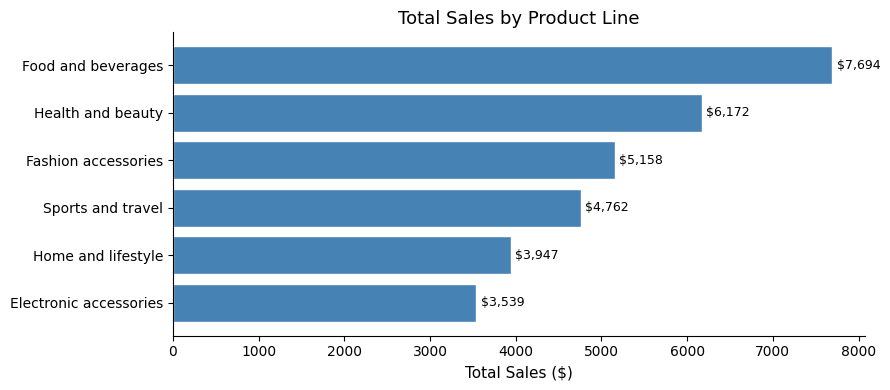

In [8]:
# Horizontal bar chart
plt.figure(figsize=(9, 4))
plt.barh(product_sales.index, product_sales.values, color='steelblue', edgecolor='white')

# Add value labels at the end of each bar
for i, value in enumerate(product_sales.values):
    plt.text(value + 50, i, f'${value:,.0f}', va='center', fontsize=9)

plt.title('Total Sales by Product Line')
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.show()

> **Finding:** Food and Beverages generates the highest revenue. Home and Lifestyle is the lowest.

---
## Step 7 — Sales by Branch and City

In [9]:
branch_sales = df.groupby('Branch')['Total'].sum()
city_sales   = df.groupby('City')['Total'].sum()

print('Sales by Branch:')
print(branch_sales.round(2))
print('\nSales by City:')
print(city_sales.round(2))

Sales by Branch:
Branch
A     8750.03
B     8876.76
C    13644.72
Name: Total, dtype: float64

Sales by City:
City
Mandalay     10496.88
Naypyitaw     8741.02
Yangon       12033.61
Name: Total, dtype: float64


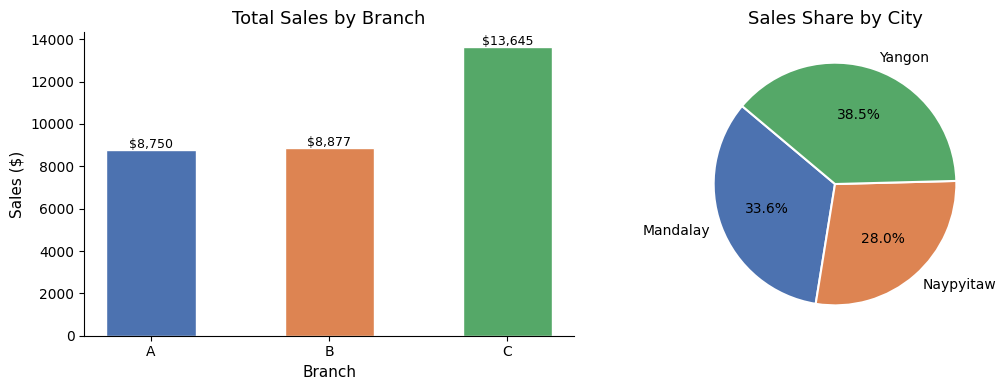

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# --- Bar chart: Branch ---
axes[0].bar(branch_sales.index, branch_sales.values, color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='white', width=0.5)
axes[0].set_title('Total Sales by Branch')
axes[0].set_ylabel('Sales ($)')
axes[0].set_xlabel('Branch')
for i, v in enumerate(branch_sales.values):
    axes[0].text(i, v + 100, f'${v:,.0f}', ha='center', fontsize=9)

# --- Pie chart: City ---
axes[1].pie(
    city_sales.values,
    labels=city_sales.index,
    autopct='%1.1f%%',
    colors=['#4C72B0', '#DD8452', '#55A868'],
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
axes[1].set_title('Sales Share by City')

plt.tight_layout()
plt.show()

> **Finding:** Branch C (Mandalay) leads in total sales. Yangon contributes the largest city share at ~38%.

---
## Step 8 — Sales by Customer Type and Gender

In [11]:
customer_sales = df.groupby('Customer type')['Total'].sum()
gender_count   = df['Gender'].value_counts()

print('Sales by Customer Type:')
print(customer_sales.round(2))
print('\nTransaction count by Gender:')
print(gender_count)

Sales by Customer Type:
Customer type
Member    13328.96
Normal    17942.55
Name: Total, dtype: float64

Transaction count by Gender:
Gender
Male      51
Female    49
Name: count, dtype: int64


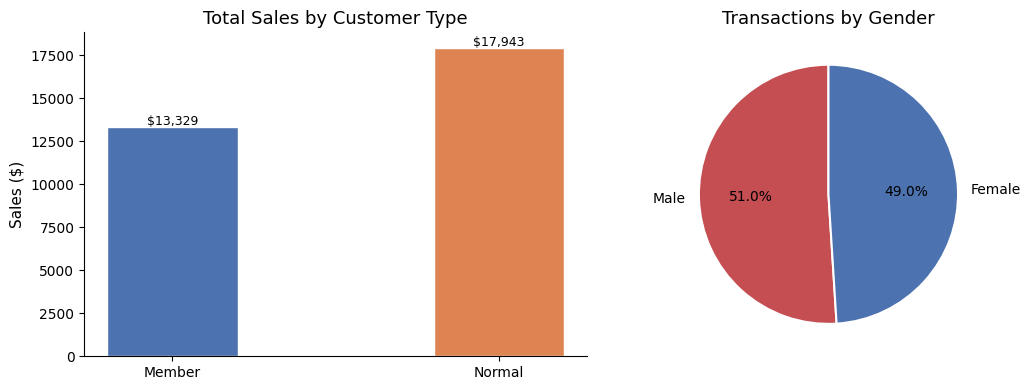

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# --- Bar chart: Customer type ---
axes[0].bar(customer_sales.index, customer_sales.values, color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.4)
axes[0].set_title('Total Sales by Customer Type')
axes[0].set_ylabel('Sales ($)')
for i, v in enumerate(customer_sales.values):
    axes[0].text(i, v + 100, f'${v:,.0f}', ha='center', fontsize=9)

# --- Pie chart: Gender ---
axes[1].pie(
    gender_count.values,
    labels=gender_count.index,
    autopct='%1.1f%%',
    colors=['#C44E52', '#4C72B0'],
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
axes[1].set_title('Transactions by Gender')

plt.tight_layout()
plt.show()

> **Finding:** Normal (walk-in) customers spend more than Members overall. Male and Female transaction counts are nearly equal.

---
## Step 9 — Payment Method Analysis

In [13]:
payment_count = df['Payment'].value_counts()

print('Transactions by Payment Method:')
print(payment_count)

Transactions by Payment Method:
Payment
Credit card    41
Ewallet        34
Cash           25
Name: count, dtype: int64


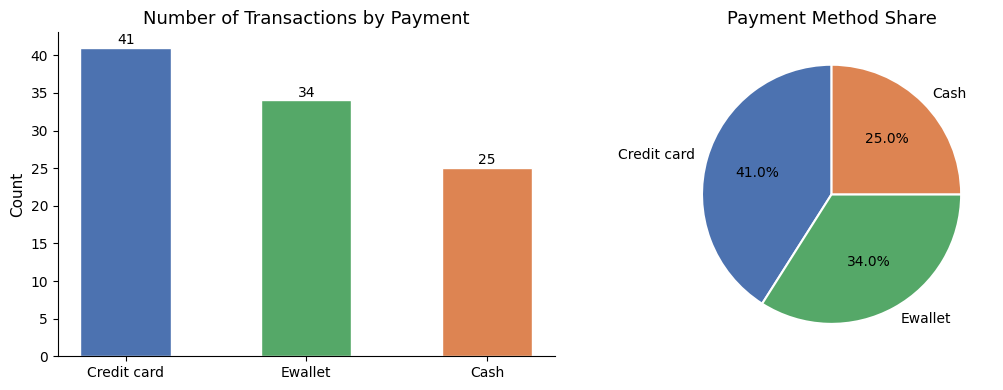

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# --- Bar chart ---
axes[0].bar(payment_count.index, payment_count.values, color=['#4C72B0', '#55A868', '#DD8452'], edgecolor='white', width=0.5)
axes[0].set_title('Number of Transactions by Payment')
axes[0].set_ylabel('Count')
for i, v in enumerate(payment_count.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontsize=10)

# --- Pie chart ---
axes[1].pie(
    payment_count.values,
    labels=payment_count.index,
    autopct='%1.1f%%',
    colors=['#4C72B0', '#55A868', '#DD8452'],
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
axes[1].set_title('Payment Method Share')

plt.tight_layout()
plt.show()

> **Finding:** Credit card is the most used payment method, followed closely by Ewallet and Cash.

---
## Step 10 — Sales by Month

In [15]:
# Sort months in calendar order
month_order  = ['January', 'February', 'March']
monthly_sales = df.groupby('Month')['Total'].sum().reindex(month_order)

print('Sales by Month:')
print(monthly_sales.round(2))

Sales by Month:
Month
January     14549.48
February    15610.34
March        1111.69
Name: Total, dtype: float64


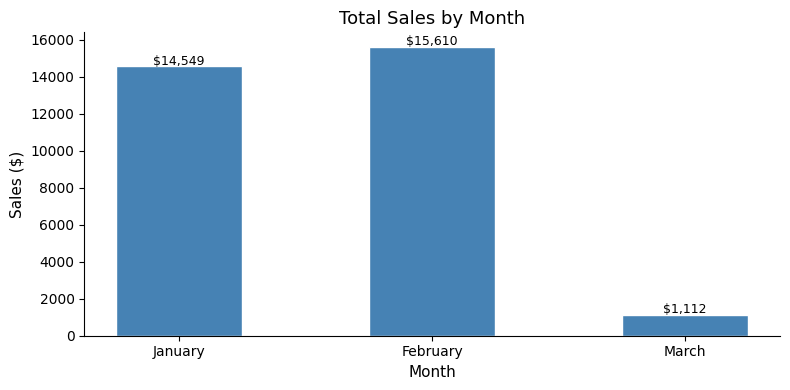

In [16]:
plt.figure(figsize=(8, 4))
plt.bar(monthly_sales.index, monthly_sales.values, color='steelblue', edgecolor='white', width=0.5)
plt.title('Total Sales by Month')
plt.ylabel('Sales ($)')
plt.xlabel('Month')
for i, v in enumerate(monthly_sales.values):
    plt.text(i, v + 100, f'${v:,.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

> **Finding:** January and February are strong months. March drops sharply — likely because the dataset only covers the first few days of March.

---
## Step 11 — Sales by Day of the Week

In [17]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_sales = df.groupby('Day')['Total'].sum().reindex(day_order)

print('Sales by Day of Week:')
print(day_sales.round(2))

Sales by Day of Week:
Day
Monday       2840.53
Tuesday      4584.70
Wednesday    5676.04
Thursday     3028.68
Friday       7668.14
Saturday     2280.92
Sunday       5192.50
Name: Total, dtype: float64


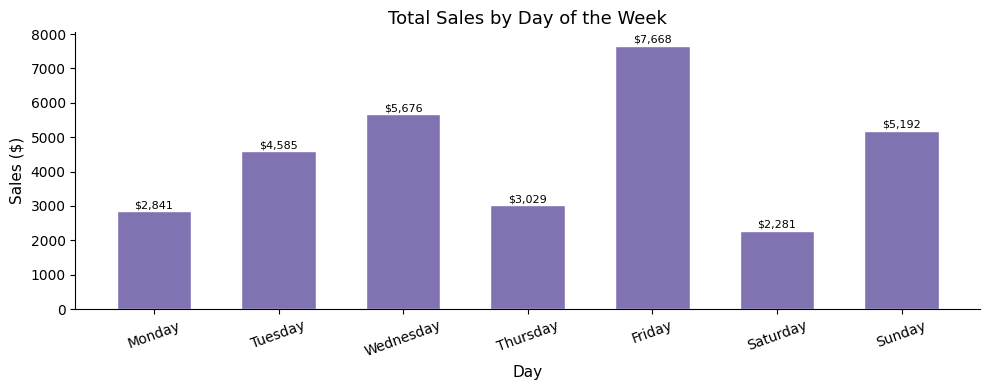

In [18]:
plt.figure(figsize=(10, 4))
plt.bar(day_sales.index, day_sales.values, color='#8172B2', edgecolor='white', width=0.6)
plt.title('Total Sales by Day of the Week')
plt.ylabel('Sales ($)')
plt.xlabel('Day')
plt.xticks(rotation=20)
for i, v in enumerate(day_sales.values):
    plt.text(i, v + 80, f'${v:,.0f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

> **Finding:** Sales are spread across the week. Tuesday and Saturday tend to be stronger days.

---
## Step 12 — Sales by Hour of the Day

In [19]:
hourly_sales = df.groupby('Hour')['Total'].sum()

print('Sales by Hour:')
print(hourly_sales.round(2))

Sales by Hour:
Hour
8     4492.82
9     2175.67
10    1474.05
11    2055.09
12    1560.78
13    2554.93
14    1506.64
15    1992.21
16    3631.70
17    3132.40
18    2078.95
19    2172.91
20    2443.36
Name: Total, dtype: float64


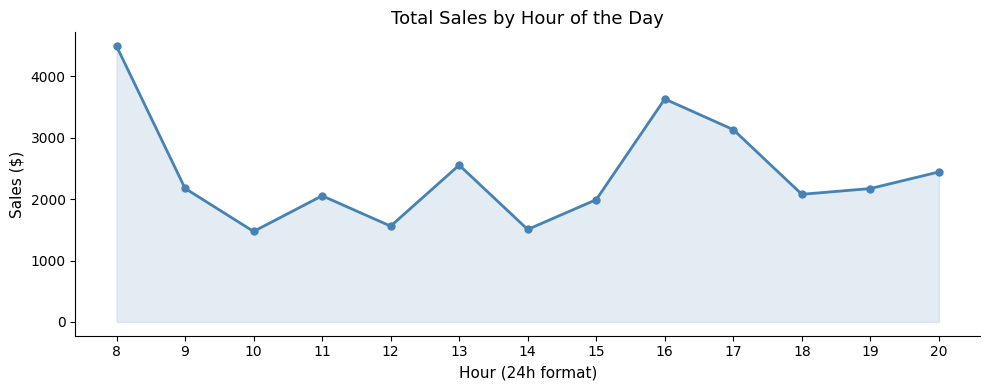

In [20]:
plt.figure(figsize=(10, 4))
plt.plot(hourly_sales.index, hourly_sales.values, color='steelblue', linewidth=2, marker='o', markersize=5)
plt.fill_between(hourly_sales.index, hourly_sales.values, alpha=0.15, color='steelblue')
plt.title('Total Sales by Hour of the Day')
plt.ylabel('Sales ($)')
plt.xlabel('Hour (24h format)')
plt.xticks(hourly_sales.index)
plt.tight_layout()
plt.show()

> **Finding:** Sales peak around 7 PM (19:00). There is a midday dip around 12–14h.

---
## Step 13 — Distribution of Transaction Totals

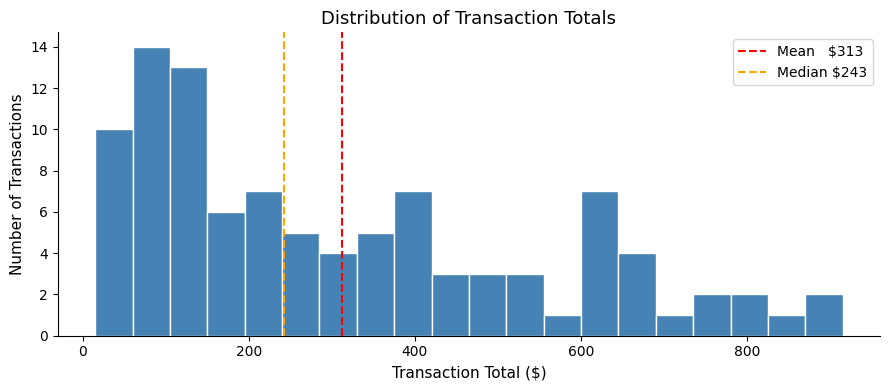

In [21]:
plt.figure(figsize=(9, 4))
plt.hist(df['Total'], bins=20, color='steelblue', edgecolor='white')

# Mark the mean and median lines
plt.axvline(np.mean(df['Total']), color='red',    linestyle='--', linewidth=1.5, label=f'Mean   ${np.mean(df["Total"]):.0f}')
plt.axvline(np.median(df['Total']), color='orange', linestyle='--', linewidth=1.5, label=f'Median ${np.median(df["Total"]):.0f}')

plt.title('Distribution of Transaction Totals')
plt.xlabel('Transaction Total ($)')
plt.ylabel('Number of Transactions')
plt.legend()
plt.tight_layout()
plt.show()

> **Finding:** Most transactions fall below $400. The distribution is right-skewed — a few large purchases pull the mean above the median.

---
## Step 14 — Unit Price vs Total Sales (Scatter Plot)

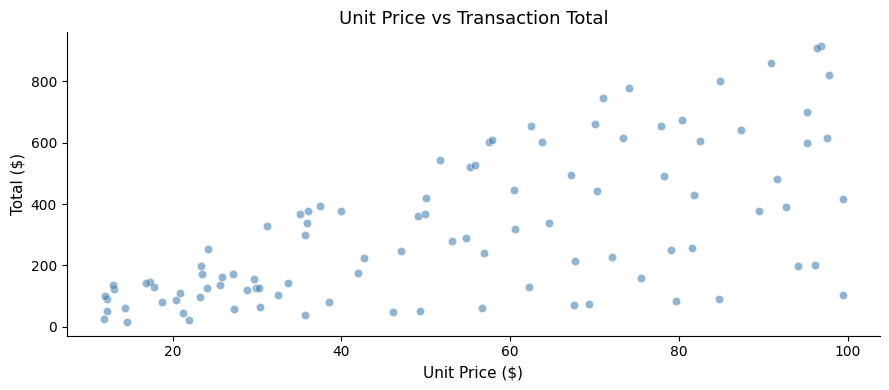

Correlation between Unit Price and Total: 0.65


In [22]:
plt.figure(figsize=(9, 4))
plt.scatter(df['Unit price'], df['Total'], alpha=0.6, color='steelblue', edgecolors='white', linewidth=0.5)
plt.title('Unit Price vs Transaction Total')
plt.xlabel('Unit Price ($)')
plt.ylabel('Total ($)')
plt.tight_layout()
plt.show()

# Use numpy to calculate the correlation coefficient
corr = np.corrcoef(df['Unit price'], df['Total'])[0, 1]
print(f'Correlation between Unit Price and Total: {corr:.2f}')

> **Finding:** There is a moderate positive correlation — higher unit prices tend to lead to higher totals, but quantity also plays a role.

---
## Step 15 — Average Quantity Sold per Product Line

In [23]:
avg_qty = df.groupby('Product line')['Quantity'].mean().sort_values()

print('Average Quantity per Product Line:')
print(avg_qty.round(2))

Average Quantity per Product Line:
Product line
Electronic accessories    4.33
Health and beauty         5.24
Fashion accessories       5.59
Sports and travel         6.08
Food and beverages        6.30
Home and lifestyle        6.43
Name: Quantity, dtype: float64


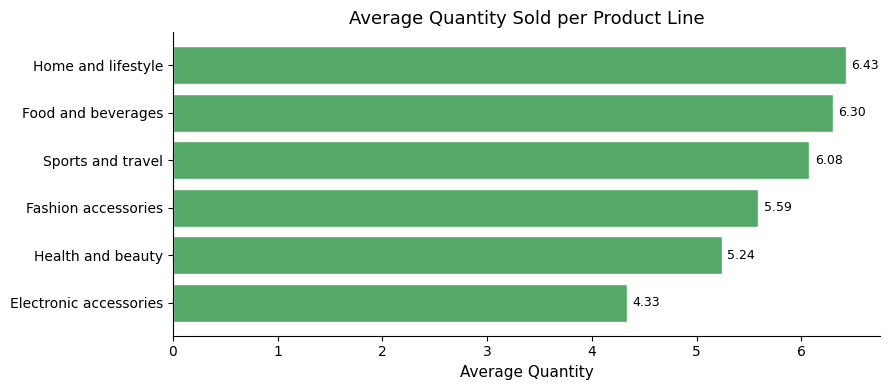

In [24]:
plt.figure(figsize=(9, 4))
plt.barh(avg_qty.index, avg_qty.values, color='#55A868', edgecolor='white')
for i, v in enumerate(avg_qty.values):
    plt.text(v + 0.05, i, f'{v:.2f}', va='center', fontsize=9)
plt.title('Average Quantity Sold per Product Line')
plt.xlabel('Average Quantity')
plt.tight_layout()
plt.show()

---
## Step 16 — Summary of Key Findings

In [25]:
print('=' * 45)
print('       SUPERMARKET SALES — KEY FINDINGS')
print('=' * 45)

print(f"\n Total Revenue          : ${df['Total'].sum():>10,.2f}")
print(f"  Average Transaction   : ${df['Total'].mean():>10.2f}")
print(f"  Median Transaction    : ${df['Total'].median():>10.2f}")
print(f"  Total Transactions    : {len(df):>10}")
print(f"  Total Items Sold      : {df['Quantity'].sum():>10}")

print('\n--- Top Performers ---')
print(f"  Best Product Line     : {df.groupby('Product line')['Total'].sum().idxmax()}")
print(f"  Best City             : {df.groupby('City')['Total'].sum().idxmax()}")
print(f"  Best Branch           : Branch {df.groupby('Branch')['Total'].sum().idxmax()}")
print(f"  Peak Hour             : {df.groupby('Hour')['Total'].sum().idxmax()}:00")
print(f"  Top Payment Method    : {df['Payment'].value_counts().idxmax()}")

print('\n--- Customer Insights ---')
print(f"  Normal customer sales : ${df[df['Customer type']=='Normal']['Total'].sum():,.2f}")
print(f"  Member sales          : ${df[df['Customer type']=='Member']['Total'].sum():,.2f}")
print(f"  Male transactions     : {df[df['Gender']=='Male'].shape[0]}")
print(f"  Female transactions   : {df[df['Gender']=='Female'].shape[0]}")
print('=' * 45)

       SUPERMARKET SALES — KEY FINDINGS

 Total Revenue          : $ 31,271.51
  Average Transaction   : $    312.72
  Median Transaction    : $    243.09
  Total Transactions    :        100
  Total Items Sold      :        565

--- Top Performers ---
  Best Product Line     : Food and beverages
  Best City             : Yangon
  Best Branch           : Branch C
  Peak Hour             : 8:00
  Top Payment Method    : Credit card

--- Customer Insights ---
  Normal customer sales : $17,942.55
  Member sales          : $13,328.96
  Male transactions     : 51
  Female transactions   : 49
